In [14]:
import PcmPy as pcm
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import os
import mat73
from vis import plot_theta_lfp, plot_theta_lfp_mean, plot_D_lfp
import warnings
from pcm_lfp import make_freq_masks

warnings.filterwarnings("ignore")

plt.style.use('default')

In [15]:
path_lfp = os.path.join(gl.baseDir, 'smp2', 'LFPs', gl.pcmDir)
monkey = 'Pert'
freqs = ['delta', 'theta', 'alpha-beta', 'alpha', 'beta','gamma']

cuePre = 0
cueIdx = 20
cuePost = 84
pertIdx = 114


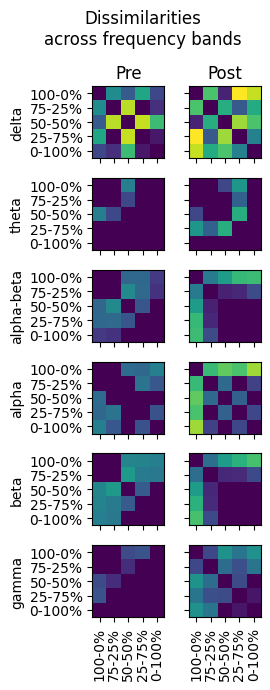

In [16]:
fig, axs = plt.subplots( len(freqs), 2, sharex='col', sharey=True, figsize=(3, 7))

for f, freq in enumerate(freqs):
    theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.plan.npy'))
    ax, h = plot_D_lfp((f, 0), axs, G_obs[:cueIdx].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.3, sqrt=True)
    ax.set_ylabel(freq)
    ax, _ = plot_D_lfp((f, 1), axs, G_obs[cueIdx:cuePost].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.3, sqrt=True)
    if f==0:
        axs[f, 0].set_title('Pre')
        axs[f, 1].set_title('Post')

fig.suptitle('Dissimilarities\nacross frequency bands')
fig.tight_layout()

plt.show()

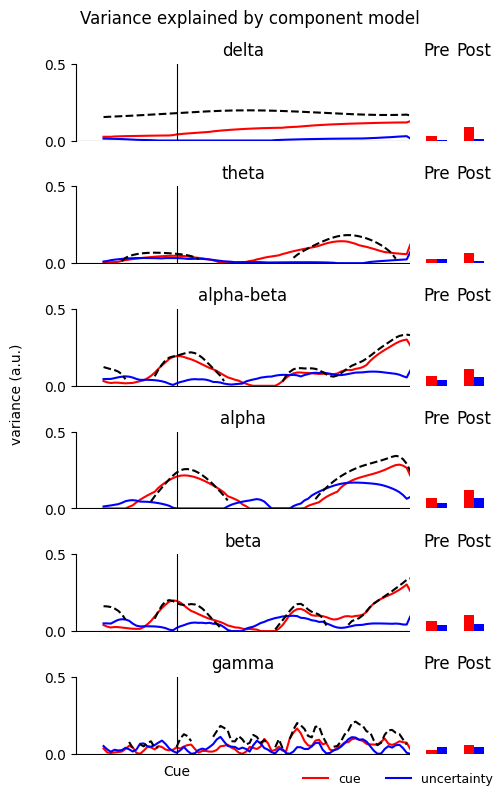

In [17]:
theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.aligned.plan.npy'))
cfg = mat73.loadmat(os.path.join(gl.baseDir, 'smp2', 'LFPs', monkey, 'cfg.mat'))['cfg']
freq_mask = make_freq_masks(cfg)
G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.aligned.plan.npy'))

fig, axs = plt.subplots(len(freqs),3, sharex='col', sharey=True, figsize=(5, 8), gridspec_kw={'width_ratios': [3, .2, .2]})

xtick = cueIdx
xtickLabel = 'Cue'
n_param = theta_in.shape[-1] - 1

var_expl = np.sqrt(np.exp(theta_in[..., :n_param]))
color = ['red', 'blue']
components = ['cue', 'uncertainty']

for f, freq in enumerate(freqs):
    tr = np.sqrt(np.trace(G_obs[freq_mask[freq]].mean(axis=0), axis1=1, axis2=2))
    var_expl_tmp = var_expl[freq_mask[freq]].mean(axis=0)
    ax = plot_theta_lfp(f, axs, var_expl_tmp, color=color)
    ax.plot(tr, ls='--', color='k')
    ax.set_title(freq)
    ax.spines['left'].set_bounds(0, .5)
    ax.axvline(xtick, color='k', lw=.8)
    ax.set_xticks([xtick])
    ax.set_ylim([-.005, .5])
    ax.set_xticklabels([xtickLabel])
    ax = plot_theta_lfp_mean(f, 1, axs, var_expl_tmp[:cueIdx].mean(axis=0), color=color)
    ax.set_title('Pre')
    ax = plot_theta_lfp_mean(f, 2, axs, var_expl_tmp[cueIdx:cuePost].mean(axis=0), color=color)
    ax.set_title('Post')

axs[0, 0].set_xlim(right=cuePost)
fig.supylabel('variance (a.u.)', fontsize='medium')
fig.legend(components, loc='lower right', fontsize=9, frameon=False, ncol=2)
fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

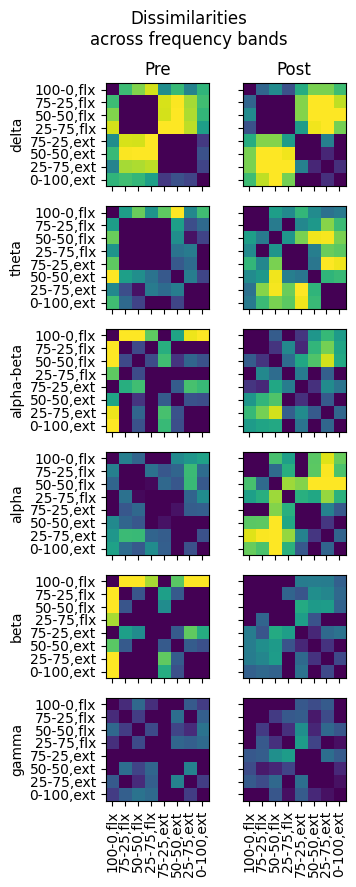

In [18]:
fig, axs = plt.subplots( len(freqs), 2, sharex='col', sharey=True, figsize=(4, 9))

conds = ['100-0,flx', '75-25,flx', '50-50,flx', '25-75,flx', '75-25,ext', '50-50,ext', '25-75,ext', '0-100,ext',]

for f, freq in enumerate(freqs):
    G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.{freq}.aligned.exec.npy'))
    ax, h = plot_D_lfp((f, 0), axs, G_obs[cuePost:pertIdx].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
    ax.set_ylabel(freq)
    ax, _ = plot_D_lfp((f, 1), axs, G_obs[pertIdx:].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
    if f==0:
        axs[f, 0].set_title('Pre')
        axs[f, 1].set_title('Post')

fig.suptitle('Dissimilarities\nacross frequency bands')
fig.tight_layout()

plt.show()

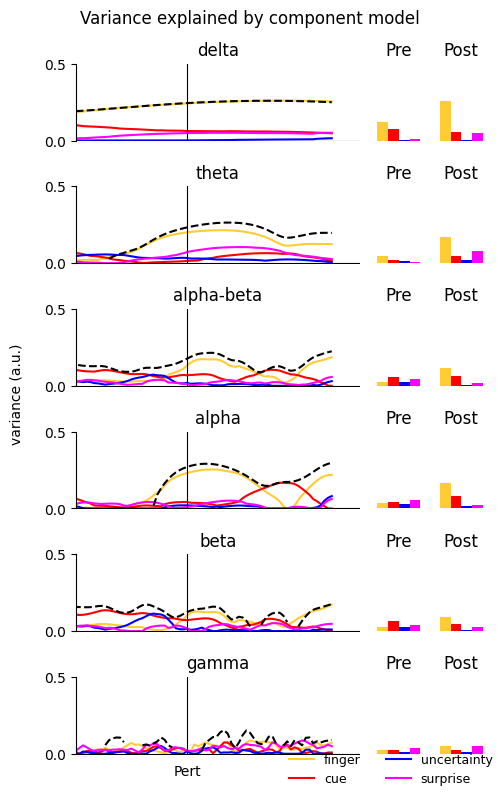

In [22]:
theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.aligned.exec.npy'))
var_expl = np.sqrt(np.exp(theta_in[..., :4]))
cfg = mat73.loadmat(os.path.join(gl.baseDir, 'smp2', 'LFPs', monkey, 'cfg.mat'))['cfg']
freq_mask = make_freq_masks(cfg)
G_obs = np.load(os.path.join(path_lfp, f'G_obs.lfp.{monkey}.PMd.aligned.exec.npy'))
color = ['#FFCC33', 'red', 'blue', 'magenta']
components = ['finger', 'cue', 'uncertainty', 'surprise']

xtick = cueIdx
xtickLabel = 'Pert'
n_param = theta_in.shape[-1] - 1

var_expl = np.sqrt(np.exp(theta_in[..., :n_param]))

fig, axs = plt.subplots(len(freqs),3, sharex='col', sharey=True, figsize=(5, 8), gridspec_kw={'width_ratios': [3, .5, .5]})

for f, freq in enumerate(freqs):
    tr = np.sqrt(np.trace(G_obs[freq_mask[freq]].mean(axis=0), axis1=1, axis2=2))
    var_expl_tmp = var_expl[freq_mask[freq]].mean(axis=0)
    ax = plot_theta_lfp(f, axs, var_expl_tmp, color=color)
    ax.plot(tr, ls='--', color='k')
    ax.set_title(freq)
    ax.spines['left'].set_bounds(0, .5)
    ax.axvline(pertIdx, color='k', lw=.8)
    ax.set_xticks([pertIdx])
    ax.set_ylim([-.005, .5])
    ax.set_xticklabels(['Pert'])
    ax = plot_theta_lfp_mean(f, 1, axs, var_expl_tmp[:pertIdx].mean(axis=0), color=color)
    ax.set_title('Pre')
    ax = plot_theta_lfp_mean(f, 2, axs, var_expl_tmp[pertIdx:].mean(axis=0), color=color)
    ax.set_title('Post')

axs[0, 0].set_xlim(left=cuePost)
fig.supylabel('variance (a.u.)', fontsize='medium')
fig.legend(components, loc='lower right', fontsize=9, frameon=False, ncol=2)
fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

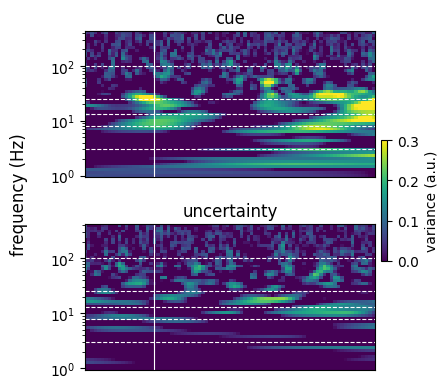

In [20]:
from vis import plot_mesh_lfp

theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.aligned.plan.npy'))
cfg = mat73.loadmat(os.path.join(gl.baseDir, 'smp2', 'LFPs', monkey, 'cfg.mat'))['cfg']
n_params = 2
components = ['cue', 'uncertainty']
var_expl = np.sqrt(np.exp(theta_in[..., :n_params]))

tAx = np.linspace(0, var_expl.shape[1], var_expl.shape[1])

fig, axs = plt.subplots(var_expl.shape[-1], sharex=True, sharey=True, figsize=(4, 4))
_, mesh = plot_mesh_lfp(axs, tAx, cfg['foi'], var_expl, components, vmin=0, vmax=.3)
for ax in axs:
    ax.set_xlim([0, cuePost])
    ax.axvline(cueIdx, color='w', lw=.8)
fig.supylabel('frequency (Hz)')
fig.tight_layout()
cbar = fig.colorbar(mesh, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('variance (a.u.)')

plt.show()

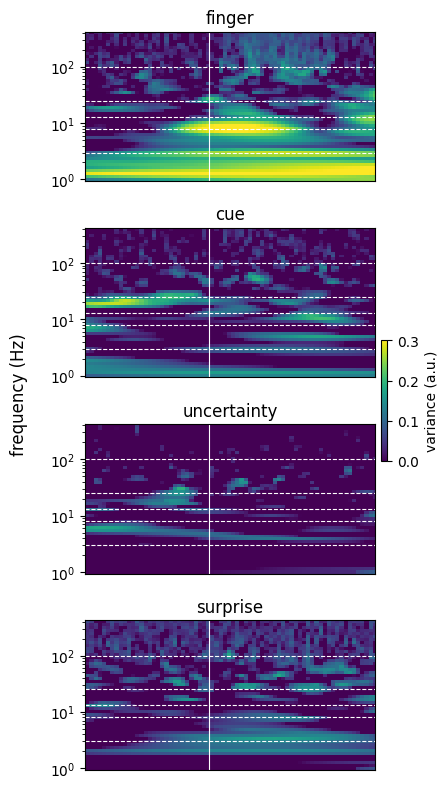

In [21]:
theta_in = np.load(os.path.join(path_lfp, f'theta_in.lfp.{monkey}.PMd.aligned.exec.npy'))
cfg = mat73.loadmat(os.path.join(gl.baseDir, 'smp2', 'LFPs', monkey, 'cfg.mat'))['cfg']
n_params = 4
components = ['finger', 'cue', 'uncertainty', 'surprise']
var_expl = np.sqrt(np.exp(theta_in[..., :n_params]))

fig, axs = plt.subplots(var_expl.shape[-1], sharex=True, sharey=True, figsize=(4, 8))
_, mesh = plot_mesh_lfp(axs, tAx, cfg['foi'], var_expl, components, vmin=0, vmax=.3)
for ax in axs:
    ax.set_xlim([cuePost, var_expl.shape[1]])
    ax.axvline(pertIdx, color='w', lw=.8)
fig.supylabel('frequency (Hz)')
fig.tight_layout()
cbar = fig.colorbar(mesh, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('variance (a.u.)')

plt.show()